In [ ]:
!pip install kagglehub

# **Load Data:**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhanushnarayananr/credit-card-fraud")

print("Path to dataset files:", path)

100%|██████████| 28.9M/28.9M [00:00<00:00, 50.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dhanushnarayananr/credit-card-fraud/versions/1


# **Import Library**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,9)
plt.rcParams['font.size'] = 10

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import mae
from tensorflow.keras.metrics import Mean
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
import os
df = pd.read_csv(os.path.join(path, 'card_transdata.csv'))
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


# **Data analysis**

In [ ]:
df.shape

(1000000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [ ]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isna().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


In [ ]:
cat_feats = [x for x in df.columns if len(df[x].unique()) <=2]
num_feats = [x for x in df.columns if x not in cat_feats]

In [ ]:
df['fraud'].value_counts()

,count
fraud,
0.0,912597
1.0,87403


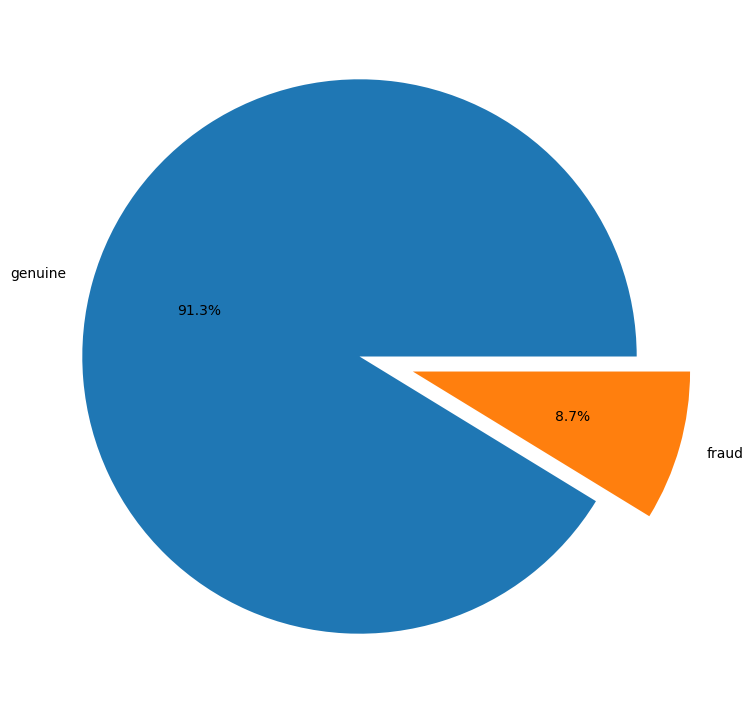

In [ ]:
vc = df['fraud'].value_counts(ascending=False)

plt.pie(x=vc.values, labels=['genuine','fraud'], explode=[0.0, 0.2], autopct='%1.1f%%')
plt.show()

### Distribution of Numerical Features by Fraud Status

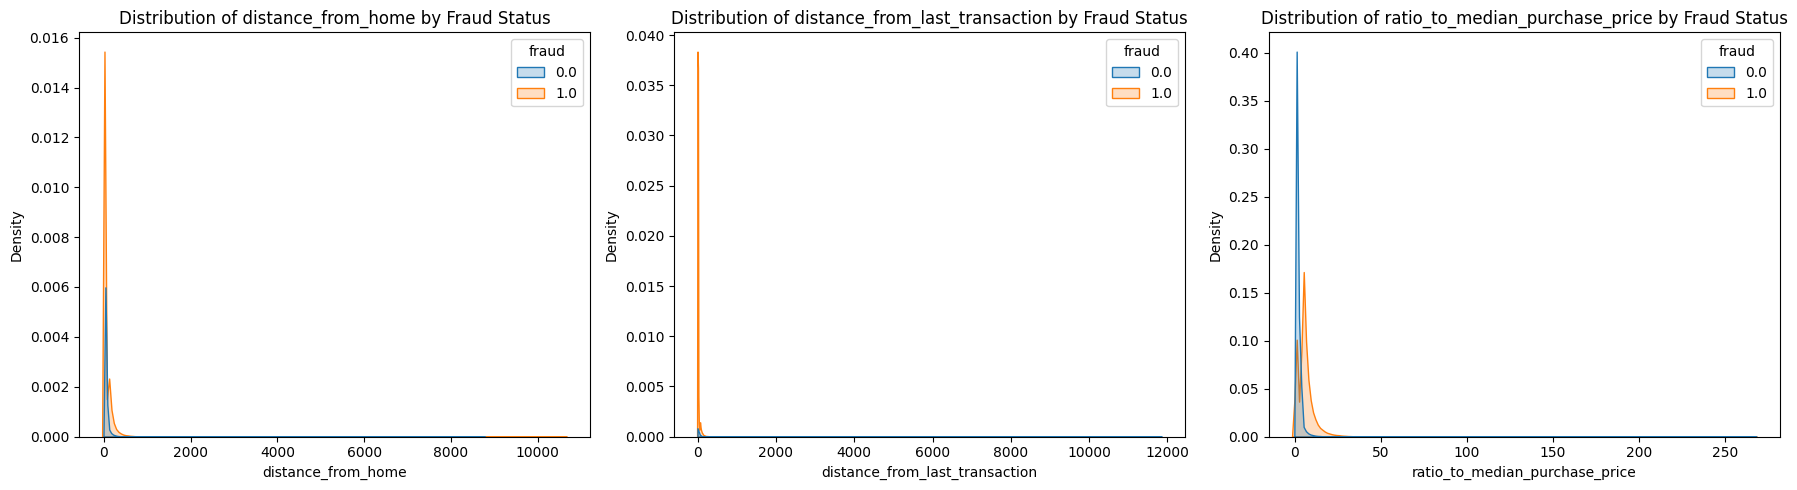

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_feats), figsize=(18, 5))
for i, col in enumerate(num_feats):
    sns.kdeplot(data=df, x=col, hue='fraud', fill=True, ax=axes[i], common_norm=False)
    axes[i].set_title(f'Distribution of {col} by Fraud Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
plt.tight_layout()
plt.show()

### Count Plots for Categorical Features by Fraud Status

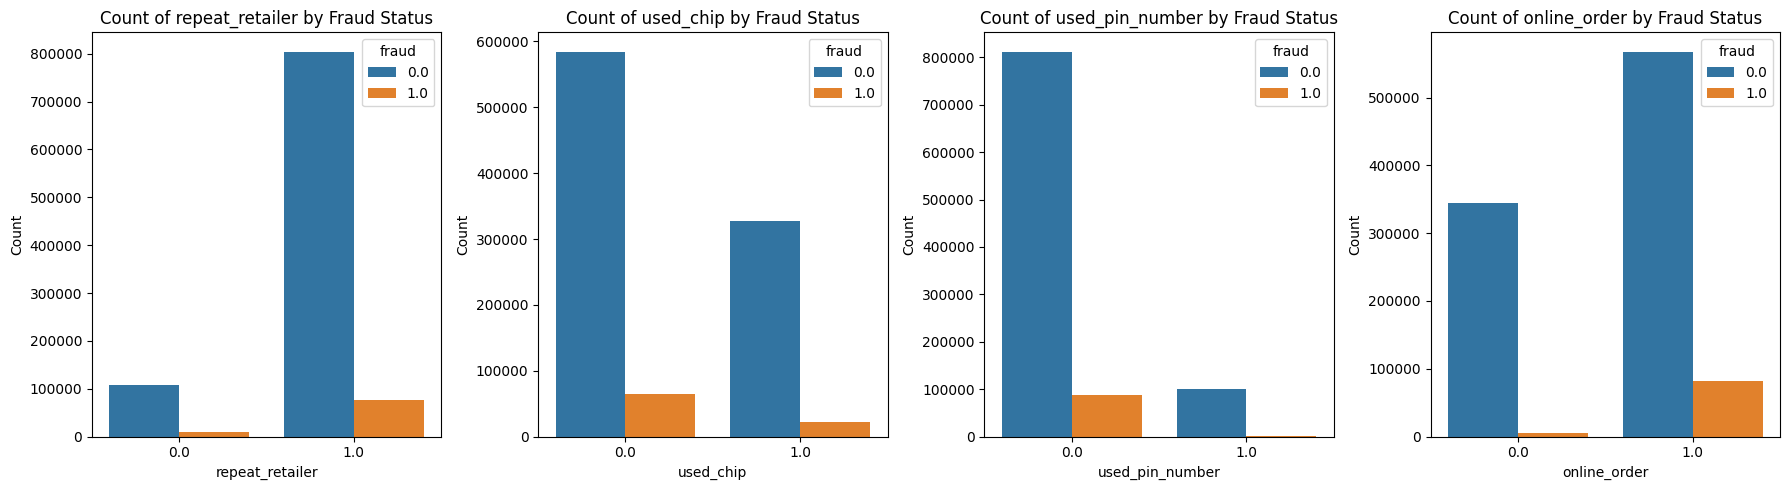

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(cat_feats[:-1]), figsize=(18, 5))
for i, col in enumerate(cat_feats[:-1]): # Exclude 'fraud' itself
    sns.countplot(data=df, x=col, hue='fraud', ax=axes[i])
    axes[i].set_title(f'Count of {col} by Fraud Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

# **Data problem**

**Inferences:**
* The dataset is heavily imbalanced
* The autoencoders only require instances of genuine samples for training
* The fraud samples will be used for testing

**Class 0 (Normal) represents standard transaction behavior**

**Class 1 (Fraud) represents rare and abnormal patterns**

Because fraudulent transactions are significantly fewer than normal ones, traditional supervised classification models may become biased toward predicting the majority class.

**⚠️ Key Challenges**

* Severe class imbalance

* Risk of high accuracy but poor fraud detection

* Minority class under-representation

* Threshold sensitivity



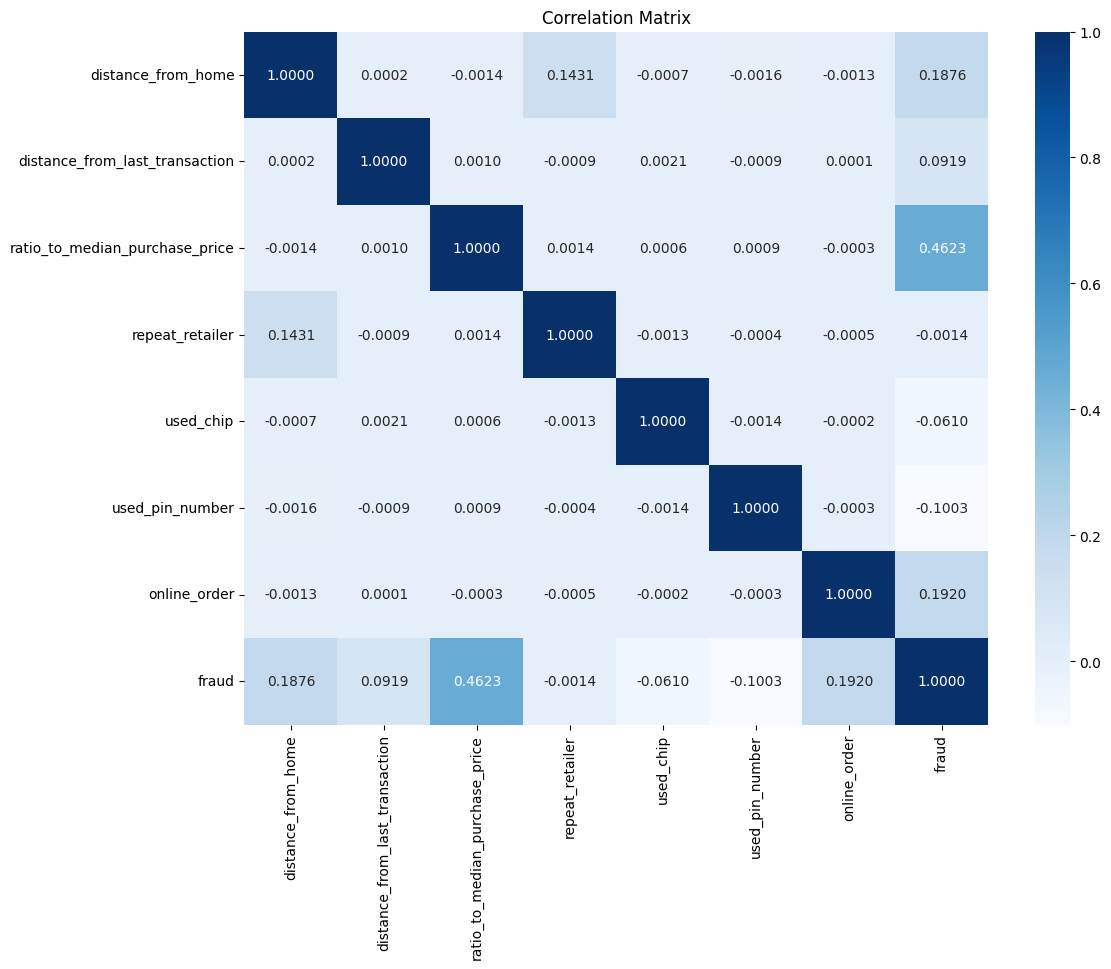

In [ ]:
sns.heatmap(df.corr(), annot=True, fmt='.4f', cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Scale numerical features
scaler = StandardScaler()
df[num_feats] = scaler.fit_transform(df[num_feats])

# Display the first few rows with scaled features
print("DataFrame after scaling numerical features:")
display(df.head())

DataFrame after scaling numerical features:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,0.477882,-0.182849,0.043491,1.0,1.0,0.0,0.0,0.0
1,-0.241607,-0.188094,-0.189300,1.0,0.0,0.0,0.0,0.0
2,-0.329369,-0.163733,-0.498812,1.0,0.0,0.0,1.0,0.0
3,-0.372854,0.021806,-0.522048,1.0,1.0,0.0,1.0,0.0
4,0.268572,-0.172968,0.142373,1.0,1.0,0.0,1.0,0.0


In [ ]:
# Define features (X) and target (y)
X = df.drop('fraud', axis=1)
y = df['fraud']

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Fraud distribution in y_train:")
display(y_train.value_counts(normalize=True))
print("Fraud distribution in y_test:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (800000, 7)
Shape of X_test: (200000, 7)
Fraud distribution in y_train:


,proportion
fraud,
0.0,0.912597
1.0,0.087402


Fraud distribution in y_test:


,proportion
fraud,
0.0,0.912595
1.0,0.087405


In [ ]:
y_train = y_train.astype(bool)
y_test = y_test.astype(bool)

X_train_genuine = X_train[~y_train]
X_test_genuine = X_test[~y_test]

X_train_fraud = X_train[y_train]
X_test_fraud = X_test[y_test]

# **Solove this problem using Anomaly Detection Using Autoencoder**

**Anomaly Detection Using Autoencoder**

To address the highly imbalanced nature of the fraud detection dataset, an Autoencoder-based anomaly detection approach is applied.

Instead of treating the problem as a traditional supervised classification task, the model is trained primarily on normal transactions (class 0) to learn typical behavioral patterns.

An Autoencoder consists of two main components:

* Encoder: Compresses input data into a low-dimensional latent representation.

* Decoder: Reconstructs the original input from this compressed representation.


In [ ]:
CODE_DIM = 2
INPUT_SHAPE = X_train.shape[1]

input_layer = Input(shape=(INPUT_SHAPE,))
x = Dense(64, activation='relu')(input_layer)
x = Dense(16, activation='relu')(x)
code = Dense(CODE_DIM, activation='relu')(x)
x = Dense(16, activation='relu')(code)
x = Dense(64, activation='relu')(x)
output_layer = Dense(INPUT_SHAPE, activation='relu')(x)

autoencoder = Model(input_layer, output_layer, name='anomaly')

autoencoder.summary()

Model: "anomaly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,177 (12.41 KB)

 Trainable params: 3,177 (12.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_name = "anomaly.weights.h5"
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            save_weights_only=True,
                            verbose=1)
earlystopping = EarlyStopping(monitor='val_loss',
                              min_delta = 0,
                              patience = 5,
                              verbose = 1,
                              restore_best_weights=True)

callbacks = [checkpoint, earlystopping]

In [ ]:
autoencoder.compile(loss='mae',
                    optimizer=Adam())

In [ ]:
history = autoencoder.fit(X_train_genuine, X_train_genuine,
                          epochs=25, batch_size=64,
                          validation_data=(X_test, X_test),
                          callbacks=callbacks, shuffle=True)

Epoch 1/25
11386/11408 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2836
Epoch 1: val_loss improved from inf to 0.28986, saving model to anomaly.weights.h5
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.2836 - val_loss: 0.2899
Epoch 2/25
11401/11408 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2370
Epoch 2: val_loss improved from 0.28986 to 0.21693, saving model to anomaly.weights.h5
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.2370 - val_loss: 0.2169
Epoch 3/25
11383/11408 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2095
Epoch 3: val_loss improved from 0.21693 to 0.21539, saving model to anomaly.weights.h5
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - loss: 0.2095 - val_loss: 0.2154
Epoch 4/25
11393/11408 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2098
Epoch 4: val_loss improved from 0.21539 to 0.21494, saving model to anomaly.weights.h5
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.2097 - val_loss: 0.2149
Epoch 5/25
11393/11408 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

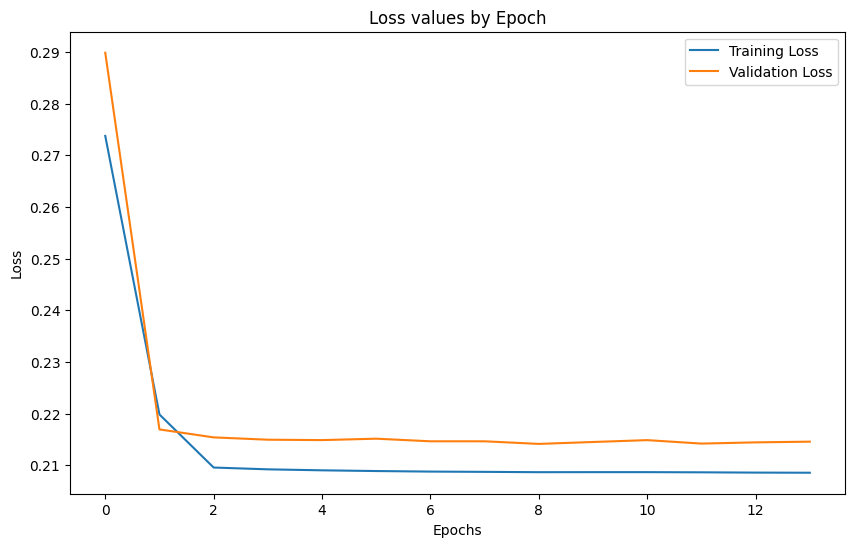

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss values by Epoch")
plt.show()

In [ ]:
reconstructions = autoencoder.predict(X_test, verbose=0)
reconstruction_error = mae(reconstructions, X_test)

In [ ]:
recons_df = pd.DataFrame({
    'error': reconstruction_error,
    'y_true': y_test
}).reset_index(drop=True)
recons_df.head()

,error,y_true
0,0.247546,False
1,0.205079,True
2,0.241333,False
3,3.267935,False
4,0.082649,False


In [ ]:
def thresholdTuning(df, iterations):

    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }

    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']

        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)

        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")

    return pd.DataFrame(thresh_df)

thresh_df = thresholdTuning(recons_df, 10)

Threshold: 0.0010	Accuracy: 0.087		Precision: 0.544	Recall Score: 0.500
Threshold: 0.0780	Accuracy: 0.183		Precision: 0.535	Recall Score: 0.540
Threshold: 0.1119	Accuracy: 0.273		Precision: 0.533	Recall Score: 0.566
Threshold: 0.1524	Accuracy: 0.371		Precision: 0.543	Recall Score: 0.612
Threshold: 0.1922	Accuracy: 0.431		Precision: 0.514	Recall Score: 0.542
Threshold: 0.2167	Accuracy: 0.499		Precision: 0.499	Recall Score: 0.496
Threshold: 0.2357	Accuracy: 0.578		Precision: 0.496	Recall Score: 0.487
Threshold: 0.2560	Accuracy: 0.669		Precision: 0.505	Recall Score: 0.514
Threshold: 0.2795	Accuracy: 0.767		Precision: 0.530	Recall Score: 0.560
Threshold: 0.3211	Accuracy: 0.853		Precision: 0.564	Recall Score: 0.573


In [ ]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.152363


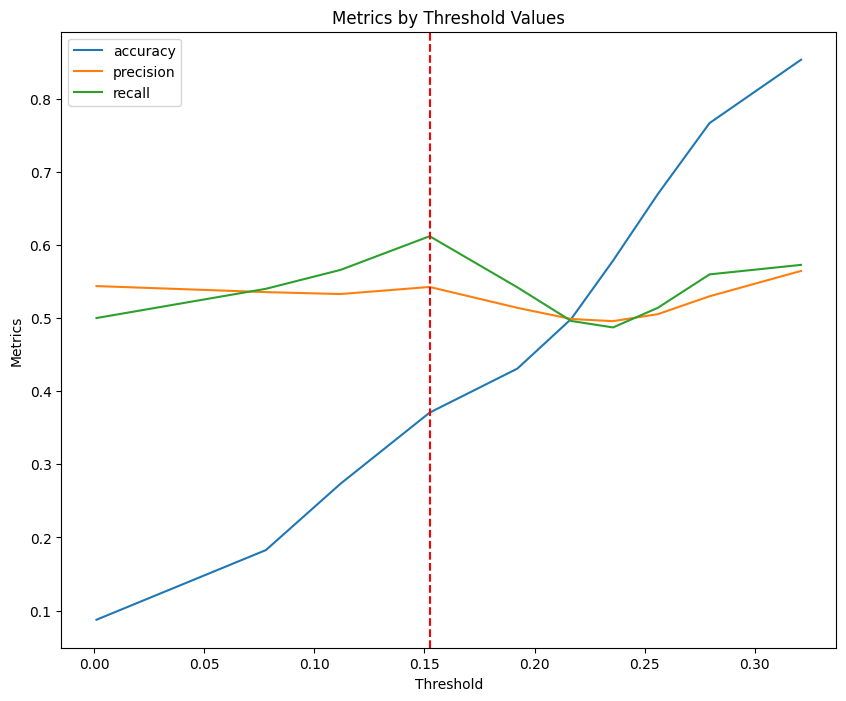

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

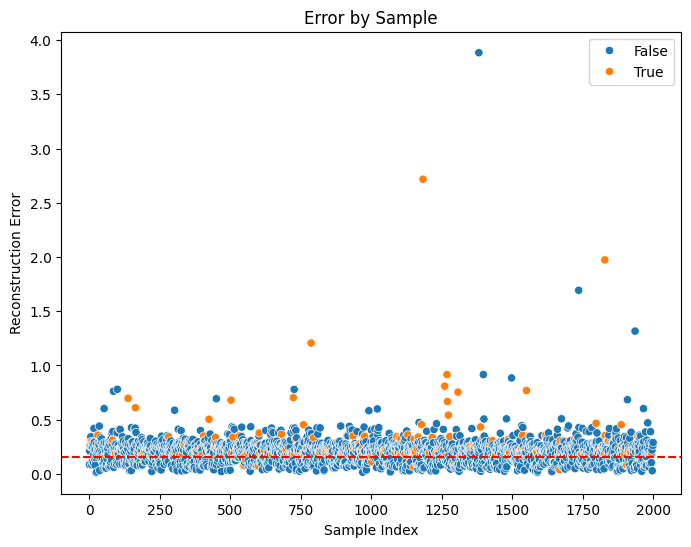

In [ ]:
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()

In [ ]:
recons_df['y_pred'] = recons_df['error'] > threshold
recons_df.head()

,error,y_true,y_pred
0,0.247546,False,True
1,0.205079,True,True
2,0.241333,False,True
3,3.267935,False,True
4,0.082649,False,False


In [ ]:
print(f"Recall Score: {recall_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")
print(f"Accuracy Score: {accuracy_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")

Recall Score: 90.424%
Accuracy Score: 37.067%


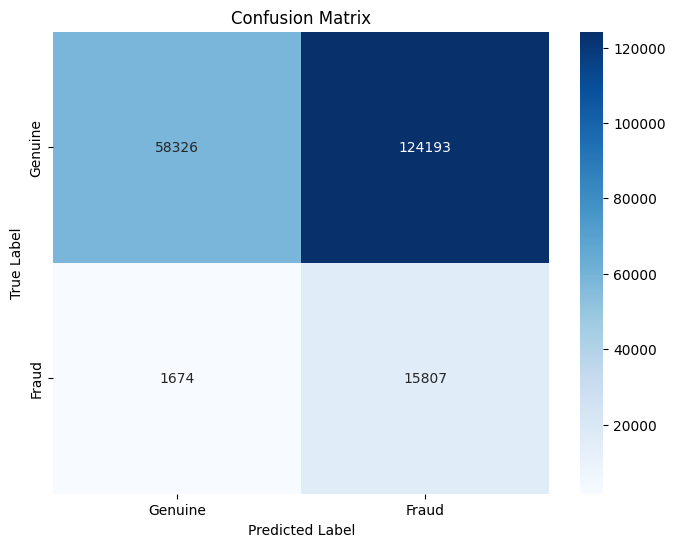

In [ ]:
cm = confusion_matrix(recons_df['y_true'], recons_df['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()